# Sampling Experiments for Imbalanced Employee Churn Data

This notebook tests various sampling techniques to handle class imbalance:
- SMOTE variants (Standard, Borderline, ADASYN)
- Undersampling methods (Random, Tomek Links, NearMiss, ENN)
- Combined approaches (SMOTE + Tomek, SMOTE + ENN)
- Class weight strategies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (precision_recall_curve, average_precision_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay)
import category_encoders as ce
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Sampling libraries
from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler, TomekLinks, NearMiss, EditedNearestNeighbours
from imblearn.combine import SMOTETomek, SMOTEENN

# Set random seed
np.random.seed(42)

## 1. Load Engineered Data

In [2]:
# Load engineered data (or original if not available)
try:
    df = pd.read_csv('../data/employee-engineered.csv')
    print("Loaded engineered dataset")
except FileNotFoundError:
    df = pd.read_csv('../data/employee-attrition.csv')
    df.columns = df.columns.str.lower()
    df['attrition'] = (df['attrition'] == 'Yes').astype(int)
    print("Loaded original dataset")

print(f"\nDataset shape: {df.shape}")
print(f"Attrition distribution:\n{df['attrition'].value_counts()}")
print(f"Attrition rate: {df['attrition'].mean():.2%}")

Loaded engineered dataset

Dataset shape: (1470, 35)
Attrition distribution:
attrition
0    1233
1     237
Name: count, dtype: int64
Attrition rate: 16.12%


## 2. Prepare Data

In [3]:
# Remove constant columns
constant_cols = ['employeecount', 'standardhours', 'over18']
df = df.drop(columns=[col for col in constant_cols if col in df.columns])

# Separate features and target
X = df.drop('attrition', axis=1)
y = df['attrition']

# Identify categorical and numerical columns
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print(f"Categorical columns ({len(cat_cols)}): {cat_cols[:5]}...")
print(f"Numerical columns ({len(num_cols)}): {num_cols[:5]}...")

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42, stratify=y
)

print(f"\nTrain set: {X_train.shape}, Attrition rate: {y_train.mean():.2%}")
print(f"Test set: {X_test.shape}, Attrition rate: {y_test.mean():.2%}")

Categorical columns (6): ['businesstravel', 'department', 'educationfield', 'jobrole', 'maritalstatus']...
Numerical columns (25): ['dailyrate', 'distancefromhome', 'education', 'employeenumber', 'environmentsatisfaction']...

Train set: (984, 31), Attrition rate: 16.16%
Test set: (486, 31), Attrition rate: 16.05%


## 3. Preprocessing Pipeline

In [4]:
# Encode categorical variables
ohe = ce.OneHotEncoder(cols=cat_cols, use_cat_names=True)
X_train_encoded = ohe.fit_transform(X_train)
X_test_encoded = ohe.transform(X_test)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

print(f"Encoded and scaled train set: {X_train_scaled.shape}")
print(f"Encoded and scaled test set: {X_test_scaled.shape}")

Encoded and scaled train set: (984, 51)
Encoded and scaled test set: (486, 51)


## 4. Baseline Model (No Sampling)

In [5]:

# ============================================================
# 4. Baseline Models (No Sampling) — same split, different models
# ============================================================

from sklearn.base import clone

# Model definitions (aligned to baseline.ipynb where possible)
models = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=10, p=1),
    "SVM (RBF)": SVC(kernel="rbf", C=1.0, gamma="scale", class_weight="balanced",
                     probability=True, random_state=42),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        min_samples_split=20,
        min_samples_leaf=10,
        ccp_alpha=0.001,
        random_state=42,
        class_weight={0: 1, 1: 7}
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        max_depth=8,
        min_samples_leaf=5,
        max_features="sqrt",
        class_weight={0: 1, 1: 7},
        random_state=42,
        n_jobs=-1
    ),
}

# Which feature matrix each model uses
X_train_map = {
    "Logistic Regression": X_train_scaled,
    "KNN": X_train_scaled,
    "SVM (RBF)": X_train_scaled,
    "Decision Tree": X_train_encoded,
    "Random Forest": X_train_encoded,
}
X_test_map = {
    "Logistic Regression": X_test_scaled,
    "KNN": X_test_scaled,
    "SVM (RBF)": X_test_scaled,
    "Decision Tree": X_test_encoded,
    "Random Forest": X_test_encoded,
}

baseline_results = {}
baseline_ap = {}

print("Baseline Models (Class Weights / No Resampling):")
print("-"*60)

for model_name, est in models.items():
    m = clone(est)
    m.fit(X_train_map[model_name], y_train)

    # Probability scores for PR/AP
    if hasattr(m, "predict_proba"):
        y_proba = m.predict_proba(X_test_map[model_name])[:, 1]
    else:
        # fallback: decision function -> convert to scores (rare for our chosen models)
        y_proba = m.decision_function(X_test_map[model_name])

    y_pred = m.predict(X_test_map[model_name])

    ap = average_precision_score(y_test, y_proba)

    baseline_results[model_name] = {
        "model": m,
        "y_pred": y_pred,
        "y_proba": y_proba,
        "ap_score": ap,
    }
    baseline_ap[model_name] = ap

    print(f"{model_name:16s} | Average Precision: {ap:.4f}")



Baseline Models (Class Weights / No Resampling):
------------------------------------------------------------
Logistic Regression | Average Precision: 0.5726
KNN              | Average Precision: 0.3753
SVM (RBF)        | Average Precision: 0.5343
Decision Tree    | Average Precision: 0.3536
Random Forest    | Average Precision: 0.4862


## 5. Sampling Experiments

In [6]:

# ============================================================
# 5. Sampling Experiments — run each sampler across all models
# ============================================================

from imblearn.base import BaseSampler

sampling_results = {}  # (sampling_name, model_name) -> dict

samplers = {
    "No Sampling": None,
    # Oversampling
    "SMOTE": SMOTE(random_state=42),
    "Borderline-SMOTE": BorderlineSMOTE(random_state=42),
    "ADASYN": ADASYN(random_state=42),
    # Undersampling
    "Random Undersampling": RandomUnderSampler(random_state=42),
    "Tomek Links": TomekLinks(),
    "NearMiss": NearMiss(version=1),
    "ENN": EditedNearestNeighbours(),
    # Combined
    "SMOTE + Tomek": SMOTETomek(random_state=42),
    "SMOTE + ENN": SMOTEENN(random_state=42),
}

def fit_eval_one(sampler_name, sampler, model_name, est):
    Xtr = X_train_map[model_name]
    Xte = X_test_map[model_name]

    if sampler is None:
        X_res, y_res = Xtr, y_train
        dist = Counter(y_train)
    else:
        X_res, y_res = sampler.fit_resample(Xtr, y_train)
        dist = Counter(y_res)

    m = clone(est)
    m.fit(X_res, y_res)

    if hasattr(m, "predict_proba"):
        y_proba = m.predict_proba(Xte)[:, 1]
    else:
        y_proba = m.decision_function(Xte)

    y_pred = m.predict(Xte)
    ap = average_precision_score(y_test, y_proba)

    sampling_results[(sampler_name, model_name)] = {
        "model": m,
        "y_pred": y_pred,
        "y_proba": y_proba,
        "ap_score": ap,
        "class_distribution": dist
    }

# Run the grid
print("Running sampling techniques across models...")
print("-"*60)

for sampler_name, sampler in samplers.items():
    print(f"\n[{sampler_name}]")
    for model_name, est in models.items():
        try:
            fit_eval_one(sampler_name, sampler, model_name, est)
            ap = sampling_results[(sampler_name, model_name)]["ap_score"]
            print(f"  - {model_name:16s}: AP={ap:.4f}")
        except Exception as e:
            print(f"  - {model_name:16s}: FAILED -> {type(e).__name__}: {e}")


Running sampling techniques across models...
------------------------------------------------------------

[No Sampling]
  - Logistic Regression: AP=0.5726
  - KNN             : AP=0.3753
  - SVM (RBF)       : AP=0.5343
  - Decision Tree   : AP=0.3536
  - Random Forest   : AP=0.4862

[SMOTE]
  - Logistic Regression: AP=0.5820
  - KNN             : AP=0.3553
  - SVM (RBF)       : AP=0.5120
  - Decision Tree   : AP=0.3587
  - Random Forest   : AP=0.5574

[Borderline-SMOTE]
  - Logistic Regression: AP=0.5578
  - KNN             : AP=0.3519
  - SVM (RBF)       : AP=0.5084
  - Decision Tree   : AP=0.3395
  - Random Forest   : AP=0.5335

[ADASYN]
  - Logistic Regression: AP=0.5599
  - KNN             : AP=0.3549
  - SVM (RBF)       : AP=0.4893
  - Decision Tree   : AP=0.3506
  - Random Forest   : AP=0.5635

[Random Undersampling]
  - Logistic Regression: AP=0.5059
  - KNN             : AP=0.3282
  - SVM (RBF)       : AP=0.5006
  - Decision Tree   : AP=0.2978
  - Random Forest   : AP=0.4830



(Sampling methods are executed in the loop above across all models.)

## 6. Results Comparison

In [7]:

# ============================================================
# 6. Results Table — AP by (Sampling Method x Model)
# ============================================================

rows = []
for (method, model_name), res in sampling_results.items():
    rows.append({
        "Method": method,
        "Model": model_name,
        "Average Precision": res["ap_score"],
        "Class Dist (Train)": dict(res["class_distribution"]),
    })

results_df = pd.DataFrame(rows)

# Improvement vs each model's own "No Sampling" baseline
baseline_lookup = results_df[results_df["Method"]=="No Sampling"].set_index("Model")["Average Precision"].to_dict()
results_df["Improvement vs No Sampling"] = results_df.apply(
    lambda r: r["Average Precision"] - baseline_lookup.get(r["Model"], np.nan),
    axis=1
)

results_df = results_df.sort_values(["Model","Average Precision"], ascending=[True, False])

display(results_df)


,Method,Model,Average Precision,Class Dist (Train),Improvement vs No Sampling
38,ENN,Decision Tree,0.384860,"{0: 477, 1: 159}",0.031235
43,SMOTE + Tomek,Decision Tree,0.364576,"{0: 765, 1: 765}",0.010951
8,SMOTE,Decision Tree,0.358731,"{0: 825, 1: 825}",0.005106
3,No Sampling,Decision Tree,0.353625,"{0: 825, 1: 159}",0.000000
28,Tomek Links,Decision Tree,0.352400,"{0: 749, 1: 159}",-0.001225
18,ADASYN,Decision Tree,0.350604,"{0: 825, 1: 834}",-0.003021
13,Borderline-SMOTE,Decision Tree,0.339511,"{0: 825, 1: 825}",-0.014115
23,Random Undersampling,Decision Tree,0.297785,"{0: 159, 1: 159}",-0.055840
33,NearMiss,Decision Tree,0.250948,"{0: 159, 1: 159}",-0.102677
48,SMOTE + ENN,Decision Tree,0.234428,"{0: 352, 1: 522}",-0.119197


## 7. Precision-Recall Curves

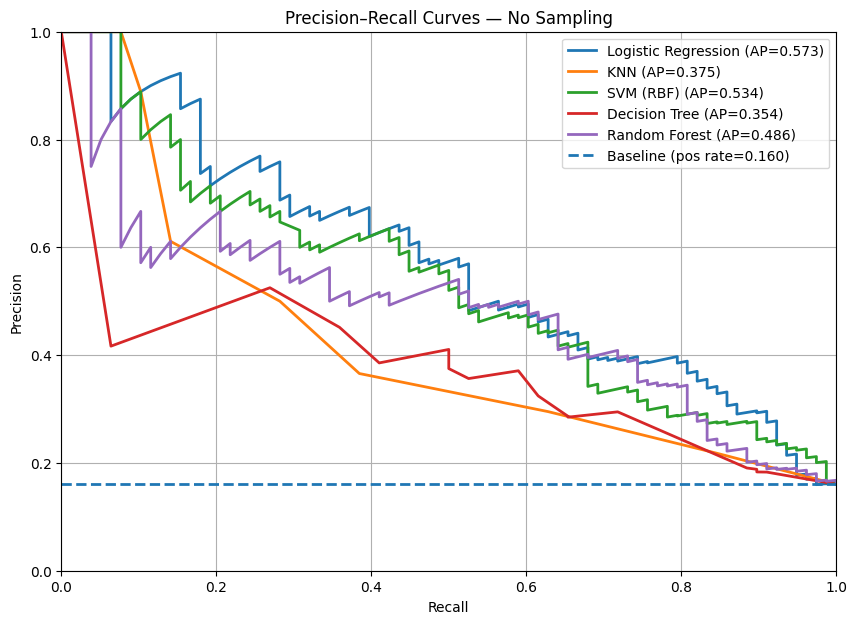

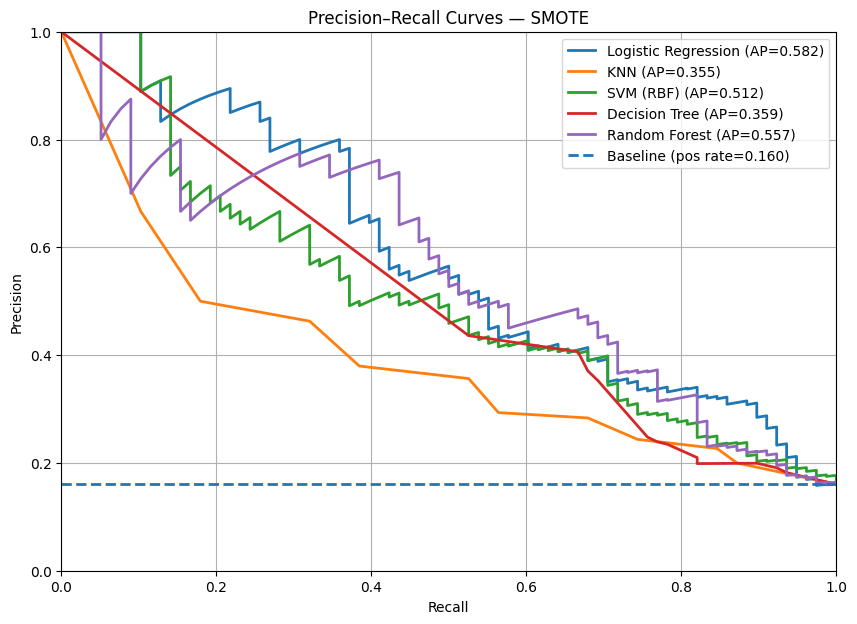

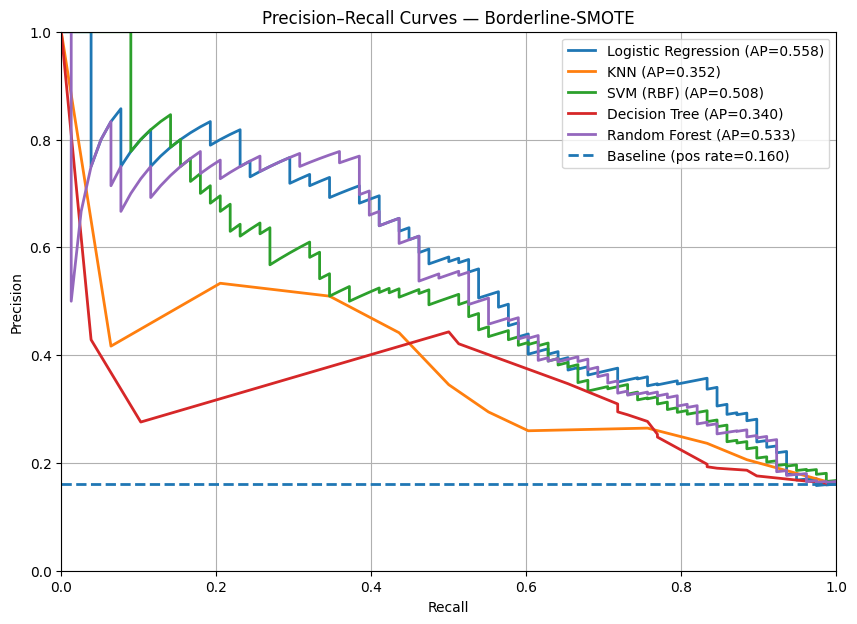

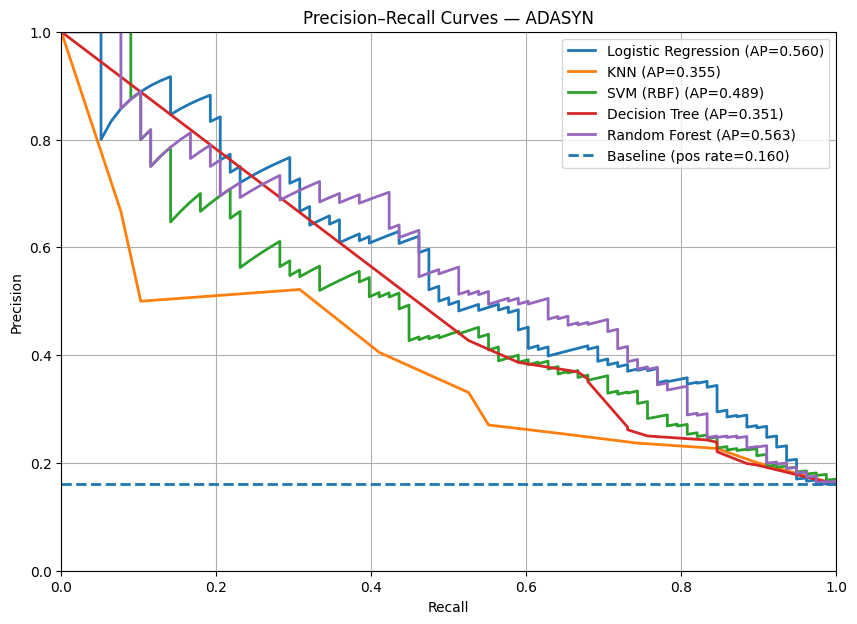

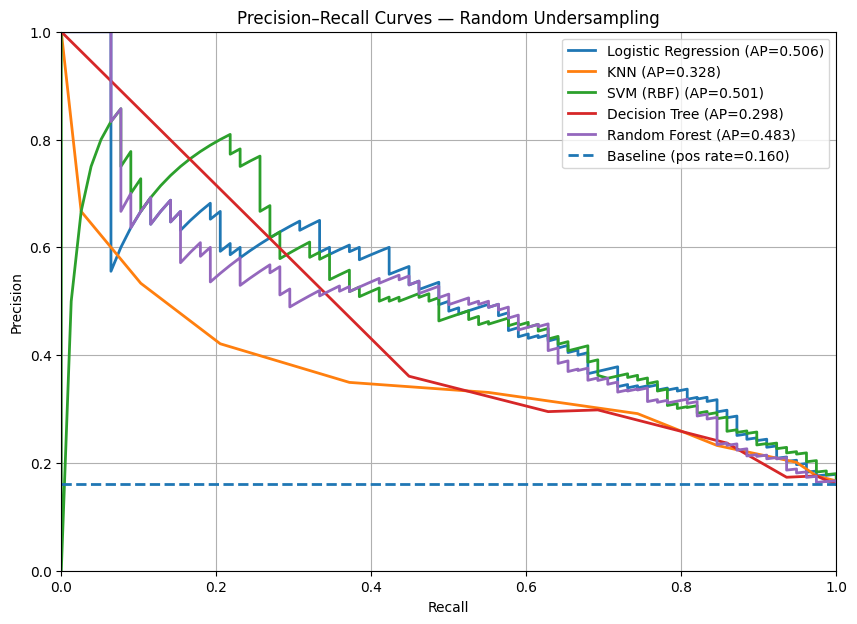

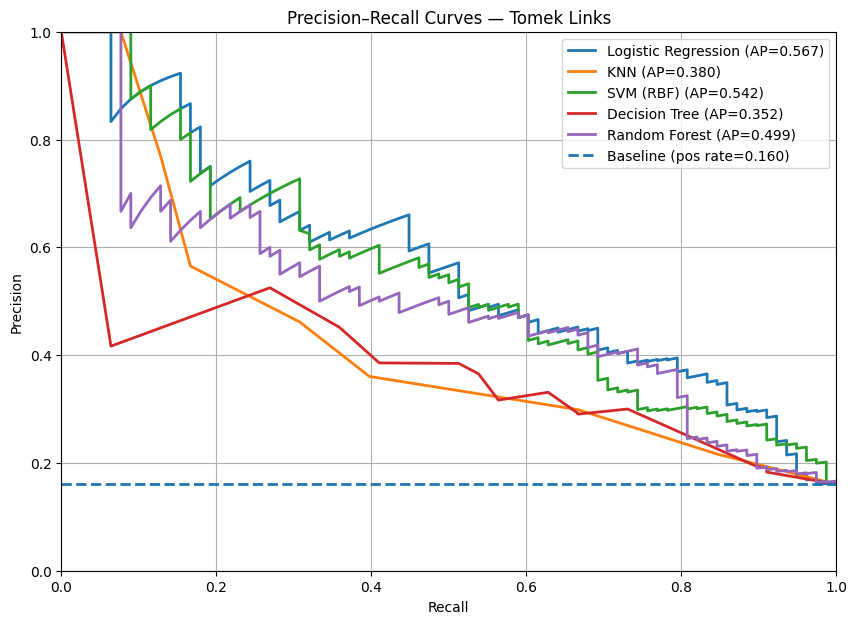

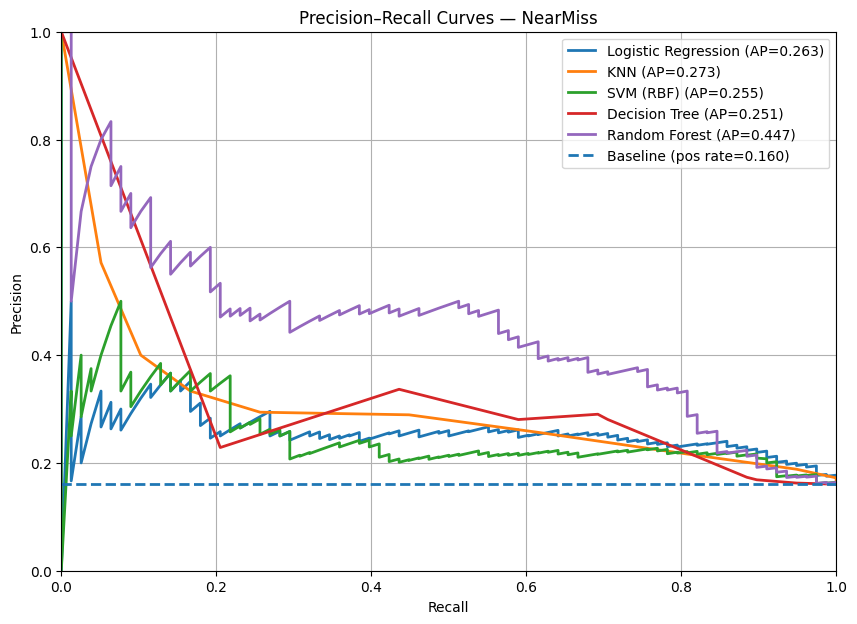

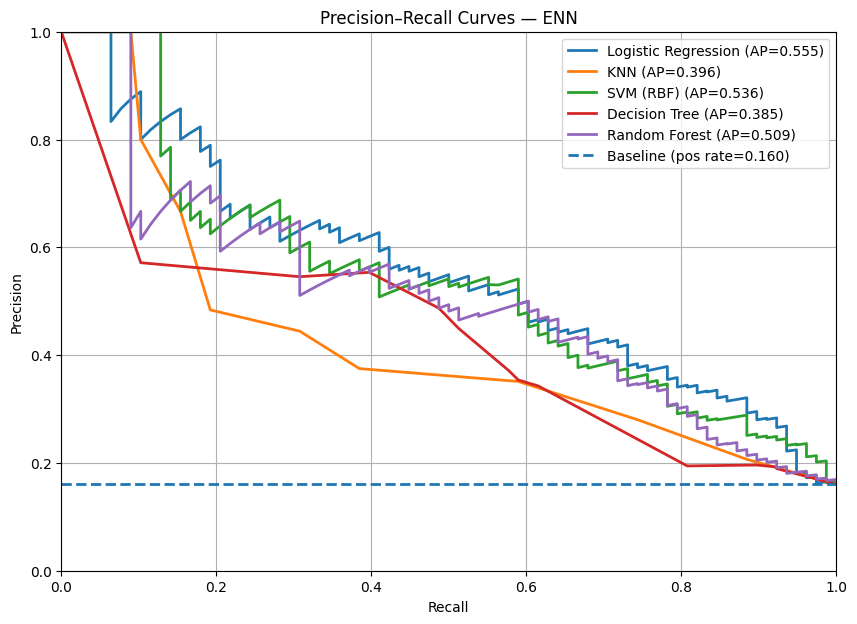

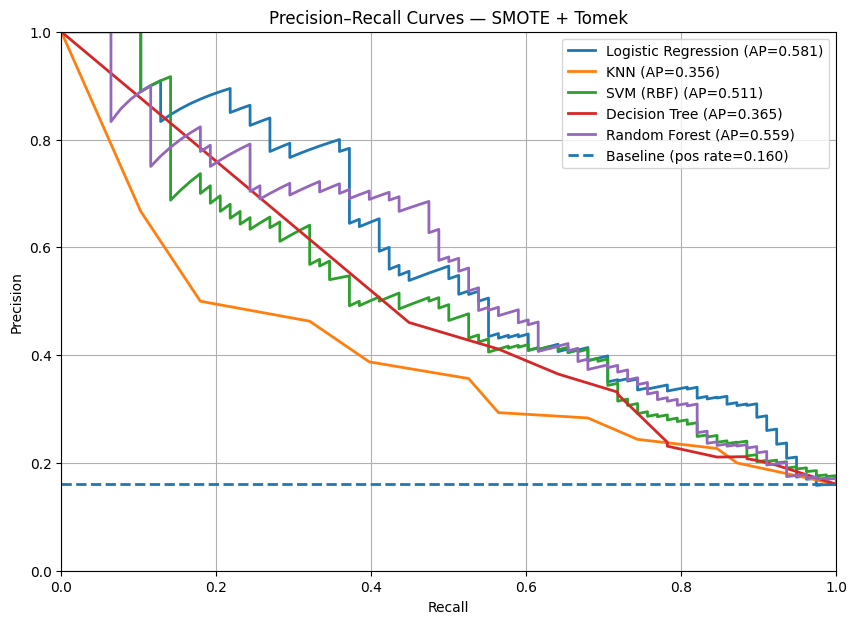

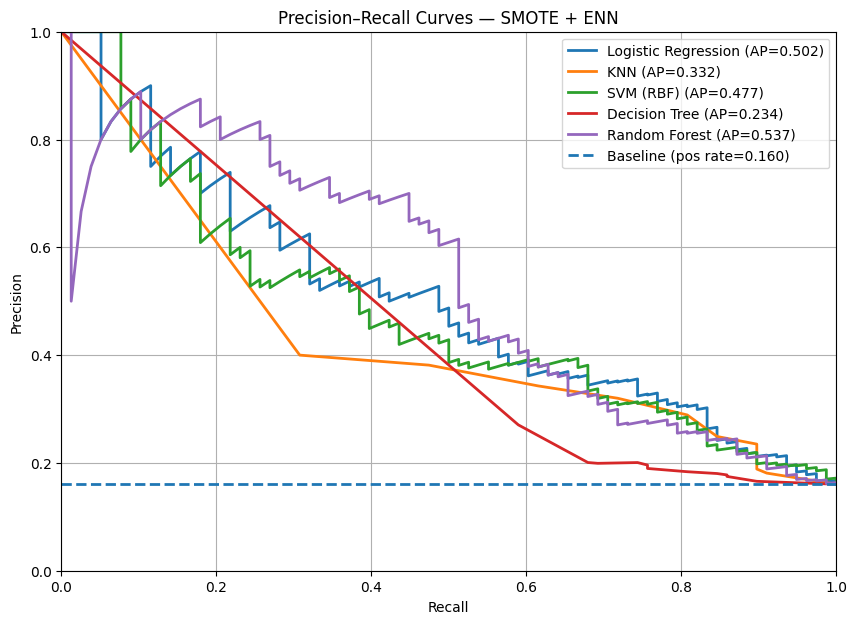

In [8]:

# ============================================================
# 7. PR Curve Chart per Sampling Technique
#    (Each chart overlays the models for that technique)
# ============================================================

# Optional: limit how many charts to show by filtering methods here
methods_to_plot = list(samplers.keys())

for method in methods_to_plot:
    plt.figure(figsize=(10, 7))

    for model_name in models.keys():
        key = (method, model_name)
        if key not in sampling_results:
            continue

        y_proba = sampling_results[key]["y_proba"]
        ap = sampling_results[key]["ap_score"]
        precision, recall, _ = precision_recall_curve(y_test, y_proba)

        plt.plot(recall, precision, label=f"{model_name} (AP={ap:.3f})", linewidth=2)

    # Baseline prevalence line
    pos_rate = float(np.mean(y_test))
    plt.hlines(pos_rate, 0, 1, linestyles="dashed", linewidth=2, label=f"Baseline (pos rate={pos_rate:.3f})")

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision–Recall Curves — {method}")
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.grid(True)
    plt.legend()
    plt.show()


## 8. Best Method Analysis

In [9]:

# ============================================================
# 8. Best Sampling Technique per Model (by Average Precision)
# ============================================================

best_by_model = (
    results_df.sort_values(["Model","Average Precision"], ascending=[True, False])
              .groupby("Model")
              .head(1)
              .reset_index(drop=True)
)

display(best_by_model)

print("\nBest method per model:")
for _, r in best_by_model.iterrows():
    print(f"- {r['Model']}: {r['Method']} (AP={r['Average Precision']:.4f}, Δ={r['Improvement vs No Sampling']:+.4f})")


,Method,Model,Average Precision,Class Dist (Train),Improvement vs No Sampling
0,ENN,Decision Tree,0.384860,"{0: 477, 1: 159}",0.031235
1,ENN,KNN,0.395716,"{0: 625, 1: 159}",0.020392
2,SMOTE,Logistic Regression,0.581985,"{0: 825, 1: 825}",0.009387
3,ADASYN,Random Forest,0.563493,"{0: 825, 1: 834}",0.077267
4,Tomek Links,SVM (RBF),0.542122,"{0: 792, 1: 159}",0.007810



Best method per model:
- Decision Tree: ENN (AP=0.3849, Δ=+0.0312)
- KNN: ENN (AP=0.3957, Δ=+0.0204)
- Logistic Regression: SMOTE (AP=0.5820, Δ=+0.0094)
- Random Forest: ADASYN (AP=0.5635, Δ=+0.0773)
- SVM (RBF): Tomek Links (AP=0.5421, Δ=+0.0078)


## 9. Save Results

In [10]:

# Save results
out_path = "../data/sampling_results_all_models.csv"
results_df.to_csv(out_path, index=False)
print(f"Results saved to: {out_path}")


Results saved to: ../data/sampling_results_all_models.csv
